In [209]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Stats / time series
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

# ML
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

plt.rcParams['figure.figsize'] = (12, 4)
pd.set_option('display.max_columns', 50)


In [210]:
df=pd.read_csv("C:\\Users\\Reetesh\\Desktop\\Timeseries Forecasting project\\gpt\\store_sales_1.csv")
df.head()

,date,store_id,sales,promotion_flag,holiday_flag
0,01-01-2022,1,184.78,0,0
1,02-01-2022,1,192.62,0,0
2,03-01-2022,1,212.68,0,0
3,04-01-2022,1,249.58,1,0
4,05-01-2022,1,223.50,0,0


In [211]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7300 entries, 0 to 7299
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            7300 non-null   str    
 1   store_id        7300 non-null   int64  
 2   sales           7300 non-null   float64
 3   promotion_flag  7300 non-null   int64  
 4   holiday_flag    7300 non-null   int64  
dtypes: float64(1), int64(3), str(1)
memory usage: 285.3 KB


In [212]:
df['date'] = pd.to_datetime(df['date'], format='%d-%m-%Y')
print(df.shape)
df.head()

(7300, 5)


,date,store_id,sales,promotion_flag,holiday_flag
0,2022-01-01,1,184.78,0,0
1,2022-01-02,1,192.62,0,0
2,2022-01-03,1,212.68,0,0
3,2022-01-04,1,249.58,1,0
4,2022-01-05,1,223.50,0,0


## 1 Group by Date - Overall Daily Sales + Decomposition + Anomalities

**Reasoning:** The task asks to forecast *overall* sales, not per-store. We `groupby('date')` and
sum `sales` across all 10 stores for a given day. `promotion_flag` is averaged (fraction of stores
running a promo that day) and `holiday_flag` is taken as `max` (a holiday is a calendar property,
same for every store on that date, so max/first are equivalent and safer than sum).

In [213]:
daily = (
    df.groupby('date')
      .agg(sales=('sales', 'sum'),
           promotion_flag=('promotion_flag', 'mean'),
           holiday_flag=('holiday_flag', 'max'))
      .reset_index()
      .sort_values('date')
      .set_index('date')
)

daily.head()

,sales,promotion_flag,holiday_flag
date,,,
2022-01-01,1947.47,0.3,1
2022-01-02,1942.29,0.2,0
2022-01-03,2099.73,0.2,1
2022-01-04,2292.64,0.3,1
2022-01-05,2274.62,0.2,0


In [214]:
# Enforce daily frequency and check for missing dates (important for ARIMA/SARIMA which need a regular index)
daily = daily.asfreq('D')
print('Date range:', daily.index.min(), 'to', daily.index.max())
print('Missing values after asfreq:\n', daily.isnull().sum())

Date range: 2022-01-01 00:00:00 to 2023-12-31 00:00:00
Missing values after asfreq:
 sales             0
promotion_flag    0
holiday_flag      0
dtype: int64


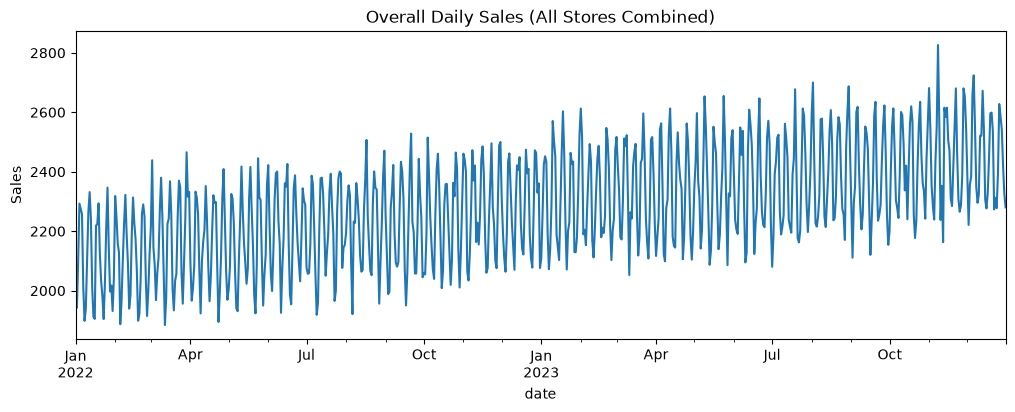

In [215]:
#plot trend
daily['sales'].plot(title='Overall Daily Sales (All Stores Combined)')
plt.ylabel('Sales')
plt.show()

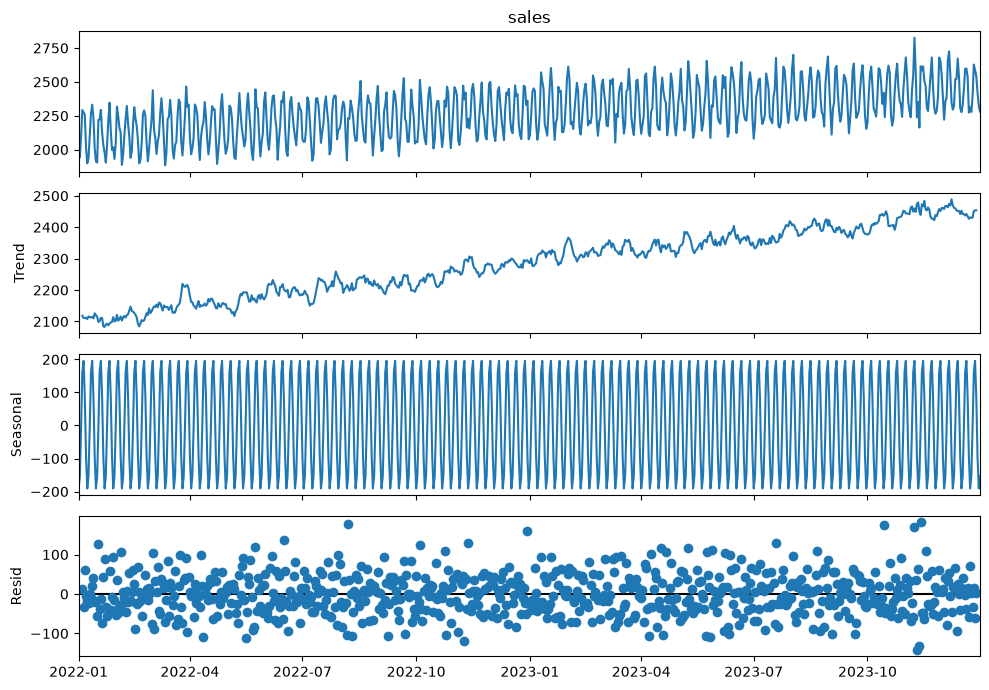

In [216]:
#Decomposition
decomposition = seasonal_decompose(daily['sales'], model='additive', period=7)

fig = decomposition.plot()
fig.set_size_inches(10, 7)
plt.tight_layout()
plt.show()


In [217]:
#Decomposition Stats
print('trend_min :', decomposition.trend.min())
print('trend_max :', decomposition.trend.max())
print('seasonal_amplitude :', decomposition.seasonal.max() - decomposition.seasonal.min())
print('residual mean :', decomposition.resid.mean())

trend_min : 2082.735714285714
trend_max : 2488.908571428571
seasonal_amplitude : 386.35282713645586
residual mean : -0.06167494779825934


In [218]:
#Residual and Anomalities
resid = decomposition.resid.dropna()
z_scores = (resid - resid.mean()) / resid.std()

anomalies = z_scores[z_scores.abs() > 3]
print(f'Detected {len(anomalies)} anomalous days (|z| > 3):')
print(anomalies)


Detected 5 anomalous days (|z| > 3):
date
2022-08-07    3.425107
2022-12-30    3.103611
2023-10-14    3.386937
2023-11-08    3.312654
2023-11-13    3.516800
Name: resid, dtype: float64


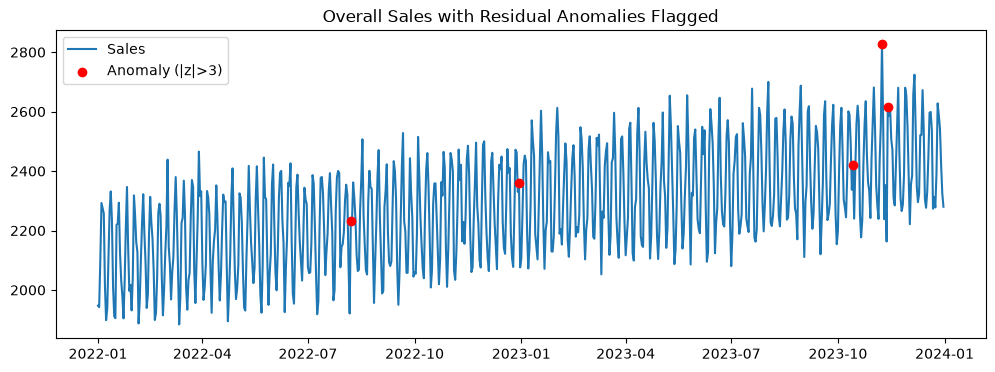

In [219]:
#plot trend with anomalities

plt.figure(figsize=(12, 4))
plt.plot(daily.index, daily['sales'], label='Sales')

plt.scatter(anomalies.index, daily.loc[anomalies.index, 'sales'],color='red', zorder=5, label='Anomaly (|z|>3)')
plt.title('Overall Sales with Residual Anomalies Flagged')
plt.legend()
plt.show()


## 2. Stationarity Check — Augmented Dickey-Fuller (ADF) Test

In [220]:
alpha=0.05

def adf_report(series, label, alpha):
    result = adfuller(series.dropna())
    print(f'--- ADF Test: {label} ---')
    print(f'ADF Statistic : {result[0]:.4f}')
    print(f'p-value       : {result[1]:.4f}')

    for i, j in result[4].items():
        print(f'   Critical Value ({i}): {j:.4f}')
    H0_NULL_hypo = 'NOT Stationary' if result[1] > alpha else 'Stationary'
    print(f'H0_NULL_hypo: {H0_NULL_hypo}\n')
    return result[1]

p_original = adf_report(daily['sales'], 'Original Series', alpha)

# If non-stationary, apply first-order differencing and re-test
if p_original > alpha :
    diff_series = daily['sales'].diff().dropna()
    p_diff = adf_report(diff_series, 'First-Order Differenced Series', alpha)

if p_diff > alpha :
    diff_series = daily['sales'].diff(7).dropna()
    p_diff = adf_report(diff_series, 'Seasonal-Order Differenced Series', alpha)


--- ADF Test: Original Series ---
ADF Statistic : -0.8029
p-value       : 0.8183
   Critical Value (1%): -3.4396
   Critical Value (5%): -2.8656
   Critical Value (10%): -2.5689
H0_NULL_hypo: NOT Stationary

--- ADF Test: First-Order Differenced Series ---
ADF Statistic : -12.6146
p-value       : 0.0000
   Critical Value (1%): -3.4396
   Critical Value (5%): -2.8656
   Critical Value (10%): -2.5689
H0_NULL_hypo: Stationary



## 3. ACF / PACF Plots & ARIMA / SARIMA Model

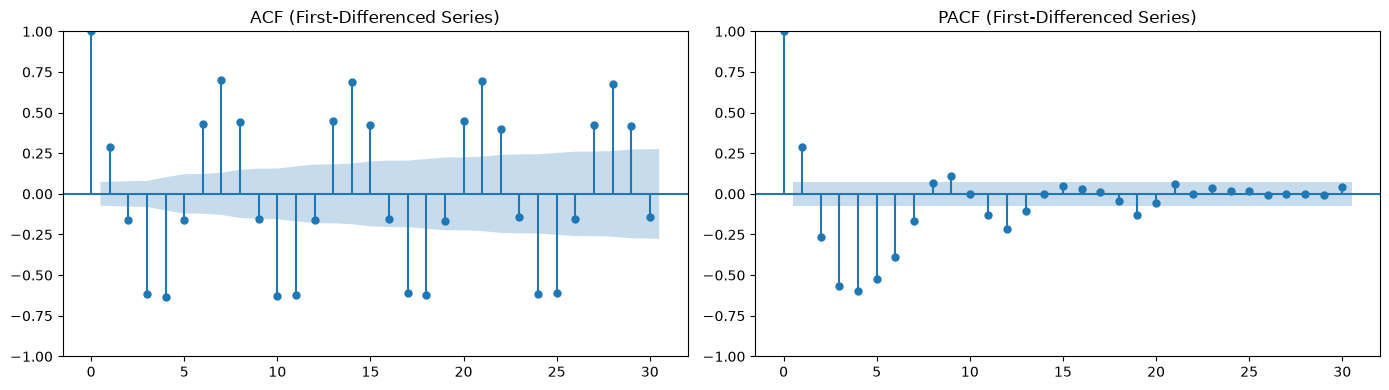

In [221]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(diff_series, lags=30, ax=axes[0])
axes[0].set_title('ACF (First-Differenced Series)')
plot_pacf(diff_series, lags=30, ax=axes[1])
axes[1].set_title('PACF (First-Differenced Series)')
plt.tight_layout()
plt.show()

### Non Seasonal order(pdq) : 
AR: Since in PACF plot spike is at lag 1 and after that its decreasing....: P=1

MA: Since in ACF plot spike there is a decay or osc pattern after first lag ....Q=1

D=1 : difference

 Seasonal order(PDQ) :



In [222]:
# Train / test split — last 60 days held out for testing (~8% of 2 years of daily data)
TEST_DAYS = 60
train_ts = daily.iloc[:-TEST_DAYS]
test_ts = daily.iloc[-TEST_DAYS:]

In [223]:
#SARIMA model fit
sarima_model = SARIMAX(
    train_ts['sales'],
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarima_fit = sarima_model.fit(disp=False)
print(sarima_fit.summary())

                                     SARIMAX Results                                     
Dep. Variable:                             sales   No. Observations:                  670
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 7)   Log Likelihood               -3570.356
Date:                           Sat, 11 Jul 2026   AIC                           7150.712
Time:                                   22:49:30   BIC                           7173.120
Sample:                               01-01-2022   HQIC                          7159.402
                                    - 11-01-2023                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0013      0.039      0.033      0.974      -0.075       0.078
ma.L1         -0.9884      0.009   -107.816

In [224]:
#sarima forecast
sarima_forecast_obj = sarima_fit.get_forecast(steps=TEST_DAYS)
sarima_pred = sarima_forecast_obj.predicted_mean
sarima_ci = sarima_forecast_obj.conf_int()

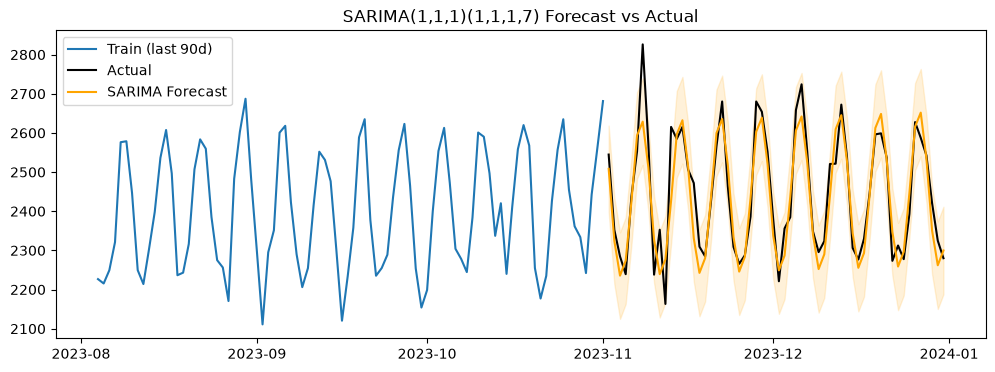

In [225]:
#Sarima plot
plt.figure(figsize=(12, 4))
plt.plot(train_ts.index[-90:], train_ts['sales'].iloc[-90:], label='Train (last 90d)')
plt.plot(test_ts.index, test_ts['sales'], label='Actual', color='black')
plt.plot(test_ts.index, sarima_pred, label='SARIMA Forecast', color='orange')
plt.fill_between(test_ts['sales'].index, sarima_ci.iloc[:, 0], sarima_ci.iloc[:, 1], color='orange', alpha=0.15)
plt.title('SARIMA(1,1,1)(1,1,1,7) Forecast vs Actual')
plt.legend()
plt.show()

In [226]:
#SARIMAX model fit
sarimax_model = SARIMAX(
    train_ts['sales'], 
    exog=train_ts[['promotion_flag', 'holiday_flag']],
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarimax_fit = sarimax_model.fit(disp=False)
print(sarimax_fit.summary())

                                     SARIMAX Results                                     
Dep. Variable:                             sales   No. Observations:                  670
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 7)   Log Likelihood               -3139.143
Date:                           Sat, 11 Jul 2026   AIC                           6292.286
Time:                                   22:49:32   BIC                           6323.657
Sample:                               01-01-2022   HQIC                          6304.451
                                    - 11-01-2023                                         
Covariance Type:                             opg                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
promotion_flag   287.8673      9.155     31.445      0.000     269.925     305.810
holiday_flag      63.6763      

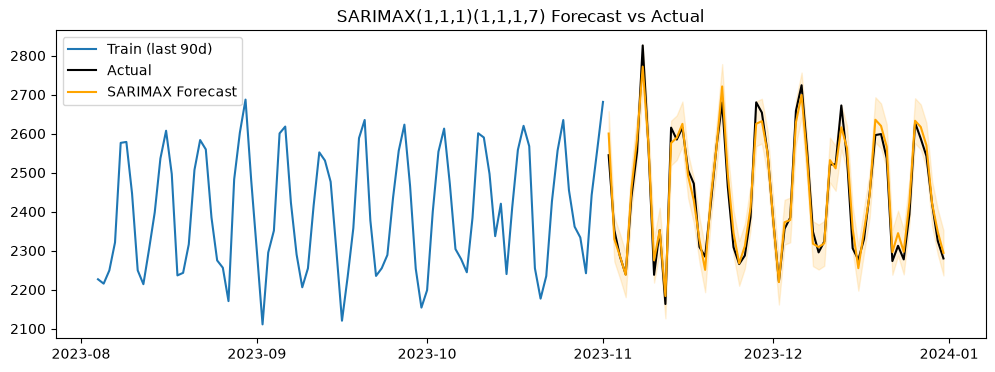

In [227]:
#SARIMAX forecast + plot
sarimax_forecast_obj = sarimax_fit.get_forecast(steps=TEST_DAYS, exog=test_ts[["promotion_flag","holiday_flag"]])
sarimax_pred = sarimax_forecast_obj.predicted_mean
sarimax_ci = sarimax_forecast_obj.conf_int()

plt.figure(figsize=(12, 4))
plt.plot(train_ts.index[-90:], train_ts['sales'].iloc[-90:], label='Train (last 90d)')
plt.plot(test_ts.index, test_ts['sales'], label='Actual', color='black')
plt.plot(test_ts.index, sarimax_pred, label='SARIMAX Forecast', color='orange')
plt.fill_between(test_ts.index, sarimax_ci.iloc[:, 0], sarimax_ci.iloc[:, 1], color='orange', alpha=0.15)
plt.title('SARIMAX(1,1,1)(1,1,1,7) Forecast vs Actual')
plt.legend()
plt.show()

In [228]:
#Sarima Vs Sarimax comparision

comparison = pd.DataFrame({
    "Model": ["SARIMA", "SARIMAX"],
    "MAE": [
        mean_absolute_error(test_ts["sales"], sarima_pred),
        mean_absolute_error(test_ts["sales"], sarimax_pred)
    ],
    "MSE": [
        mean_squared_error(test_ts["sales"], sarima_pred),
        mean_squared_error(test_ts["sales"], sarimax_pred)
    ],
    "R2": [
        r2_score(test_ts["sales"], sarima_pred),
        r2_score(test_ts["sales"], sarimax_pred)
    ],
    "MAPE": [
        np.mean(np.abs((test_ts["sales"] - sarima_pred) / test_ts["sales"])) * 100,
        np.mean(np.abs((test_ts["sales"] - sarimax_pred) / test_ts["sales"])) * 100
    ]
})

comparison = comparison.sort_values(by="MAE")
display(comparison)

,Model,MAE,MSE,R2,MAPE
1,SARIMAX,21.928212,718.529700,0.969092,0.887826
0,SARIMA,47.155535,3842.597119,0.834708,1.918567


* In comparision SARIMAX performed better

## 4. Feature Engineering — Lag, Calendar & Rolling Features


In [229]:
feat = daily.copy()

# Calendar features
feat['dayofweek'] = feat.index.dayofweek
feat['month'] = feat.index.month
feat['day'] = feat.index.day
feat['quarter'] = feat.index.quarter
feat['is_weekend'] = (feat['dayofweek'] >= 5).astype(int)

# Lag features
for lag in [1, 7, 14, 30]:
    feat[f'lag_{lag}'] = feat['sales'].shift(lag)

# Rolling mean/std (shifted by 1 to avoid leakage)
for w in [7, 14, 30]:
    feat[f'roll_mean_{w}'] = feat['sales'].shift(1).rolling(w).mean()
    feat[f'roll_std_{w}'] = feat['sales'].shift(1).rolling(w).std()

feat = feat.dropna()  # drop rows without full lag/rolling history
print('Feature matrix shape:', feat.shape)
feat.head()


Feature matrix shape: (700, 18)


,sales,promotion_flag,holiday_flag,dayofweek,month,day,quarter,is_weekend,lag_1,lag_7,lag_14,lag_30,roll_mean_7,roll_std_7,roll_mean_14,roll_std_14,roll_mean_30,roll_std_30
date,,,,,,,,,,,,,,,,,,
2022-01-31,2042.52,0.0,1,0,1,31,1,0,1931.43,2031.05,2218.99,1947.47,2096.872857,144.742106,2104.039286,138.668571,2096.361000,149.289535
2022-02-01,2318.25,0.5,0,1,2,1,1,0,2042.52,2212.10,2223.45,1942.29,2098.511429,143.935433,2091.434286,135.397760,2099.529333,147.011935
2022-02-02,2250.13,0.1,1,2,2,2,1,0,2318.25,2346.51,2293.57,2099.73,2113.675714,162.315249,2098.205714,144.567920,2112.061333,149.154601
2022-02-03,2160.00,0.2,0,3,2,3,1,0,2250.13,2142.69,2124.46,2292.64,2099.907143,142.102307,2095.102857,140.460090,2117.074667,151.238866
2022-02-04,2127.45,0.5,1,4,2,4,1,0,2160.00,1996.98,2032.85,2274.62,2102.380000,143.117881,2097.641429,141.349827,2112.653333,147.829771


In [230]:
X = feat.drop(columns=['sales'])
y = feat['sales']

# Time-based split (no shuffling) — last 15% as test set, consistent with how forecasting is used in production
split_idx = int(len(feat) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
print('Train size:', len(X_train), '| Test size:', len(X_test))


Train size: 560 | Test size: 140


## 5 & 6. Model Fitting + Hyperparameter Tuning

**Reasoning:** We use `TimeSeriesSplit` (not standard k-fold) for cross-validation during tuning —
this respects temporal order and never trains on future data to predict the past, which would be
data leakage in a forecasting context.

- **Linear Regression** — simple baseline, no tuning needed.
- **Random Forest** — small grid over `n_estimators` / `max_depth` to control overfitting.
- **XGBoost** — small grid over `n_estimators`, `max_depth`, `learning_rate`.

Grids are kept intentionally small (per the "keep it simple" rule) — enough to demonstrate the
tuning process without an expensive search.

In [231]:
tscv = TimeSeriesSplit(n_splits=3)

# Linear Regression (baseline, no tuning)
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)


In [ ]:
# Random Forest + GridSearchCV
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 8, None],
    'min_samples_leaf': [1, 2, 5],
    'max_features': ['sqrt', 0.8, 1.0]
}
rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    rf_param_grid,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)
rf_grid.fit(X_train, y_train)
print('Best RF params:', rf_grid.best_params_)

rf_model = rf_grid.best_estimator_
rf_pred = rf_model.predict(X_test)

Best RF params: {'max_depth': 10, 'n_estimators': 200}


In [ ]:
# XGBoost + GridSearchCV 

xgb_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.85, 1.0],
    'colsample_bytree': [0.7, 0.85, 1.0]
}
xgb_grid = GridSearchCV(
    XGBRegressor(random_state=42, verbosity=0),
    xgb_param_grid,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)
xgb_grid.fit(X_train, y_train)
print('Best XGB params:', xgb_grid.best_params_)

xgb_model = xgb_grid.best_estimator_
xgb_pred = xgb_model.predict(X_test)

Best XGB params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}


## 7. Model Evaluation — MAE, MSE, R², MAPE

**Reasoning:** No single metric tells the whole story:
- **MAE** — average absolute error, in original sales units, easy to communicate to business.
- **MSE** — penalises large errors more, useful to catch models with occasional big misses.
- **R²** — proportion of variance explained, good for quick "is this even better than the mean" check.
- **MAPE** — scale-free percentage error, useful for comparing performance intuitively.

In [235]:
def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return {'Model': name, 'MAE': mae, 'MSE': mse, 'R2': r2, 'MAPE (%)': mape}

results = []
results.append(evaluate(test_ts['sales'].values, sarima_pred.values, 'SARIMA(1,1,1)(1,1,1,7)'))
results.append(evaluate(y_test.values, lr_pred, 'Linear Regression'))
results.append(evaluate(y_test.values, rf_pred, 'Random Forest (tuned)'))
results.append(evaluate(y_test.values, xgb_pred, 'XGBoost (tuned)'))

results_df = pd.DataFrame(results).set_index('Model').round(3)
results_df


,MAE,MSE,R2,MAPE (%)
Model,,,,
"SARIMA(1,1,1)(1,1,1,7)",47.156,3842.597,0.835,1.919
Linear Regression,34.556,1818.619,0.923,1.427
Random Forest (tuned),52.403,4452.255,0.811,2.141
XGBoost (tuned),44.516,3078.569,0.870,1.819


## 8. Final Model Comparison

**Note on comparability:** SARIMA is evaluated on the last 60 days (pure time-series holdout); the
ML models are evaluated on the last 20% of the feature-engineered set (~ days) because they lose
the first 30 rows to lag/rolling-window construction. Both are legitimate **out-of-time** holdouts,
so the metrics are still comparable in spirit — lower MAE/MSE/MAPE and higher R² indicates the
better forecaster.

In [237]:
results = pd.DataFrame({
    "Model":["SARIMA","SARIMAX","Linear Regression","Random Forest","XGBoost"],
    "MAE":[
        mean_absolute_error(test_ts["sales"], sarima_pred),
        mean_absolute_error(test_ts["sales"], sarimax_pred),
        mean_absolute_error(y_test, lr_pred),
        mean_absolute_error(y_test, rf_pred),
        mean_absolute_error(y_test, xgb_pred)
    ],
    "MSE":[
        mean_squared_error(test_ts["sales"], sarima_pred),
        mean_squared_error(test_ts["sales"], sarimax_pred),
        mean_squared_error(y_test, lr_pred),
        mean_squared_error(y_test, rf_pred),
        mean_squared_error(y_test, xgb_pred)
    ],
    "R2":[
        r2_score(test_ts["sales"], sarima_pred),
        r2_score(test_ts["sales"], sarimax_pred),
        r2_score(y_test, lr_pred),
        r2_score(y_test, rf_pred),
        r2_score(y_test, xgb_pred)
    ],
    "MAPE":[
        np.mean(np.abs((test_ts["sales"] - sarima_pred) / test_ts["sales"])) * 100,
        np.mean(np.abs((test_ts["sales"] - sarimax_pred) / test_ts["sales"])) * 100,
        np.mean(np.abs((y_test - lr_pred) / y_test)) * 100,
        np.mean(np.abs((y_test - rf_pred) / y_test)) * 100,
        np.mean(np.abs((y_test - xgb_pred) / y_test)) * 100
    ]
})

display(results.sort_values("MAE"))

,Model,MAE,MSE,R2,MAPE
1,SARIMAX,21.928212,718.529700,0.969092,0.887826
2,Linear Regression,34.555753,1818.619397,0.922960,1.427376
4,XGBoost,44.516134,3078.568824,0.869586,1.819192
0,SARIMA,47.155535,3842.597119,0.834708,1.918567
3,Random Forest,52.403351,4452.255446,0.811394,2.141295


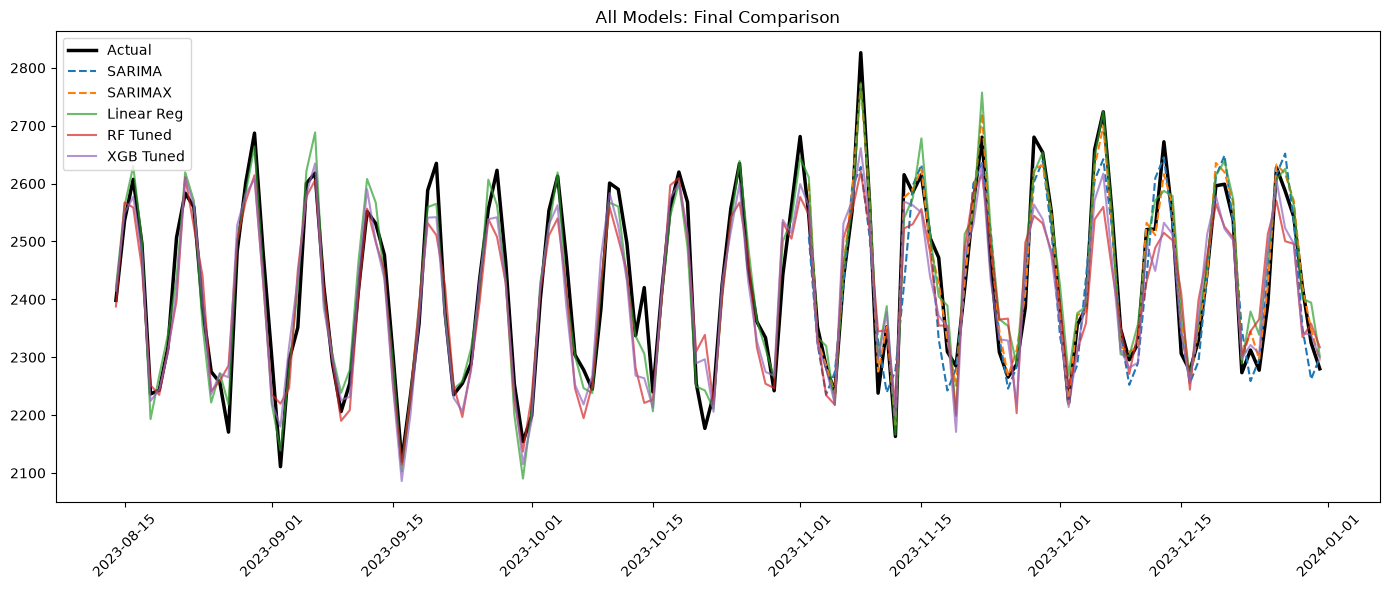

In [250]:
# Plot all model predictions
plt.figure(figsize=(14, 6))
plt.plot(X_test.index, y_test, label='Actual', color='black', linewidth=2.5)

# Align ARIMA/SARIMA dates
arima_dates = test_ts.index
plt.plot(test_ts.index, sarima_pred, label='SARIMA', linestyle='--')
plt.plot(test_ts.index, sarimax_pred, label='SARIMAX', linestyle='--')
plt.plot(y_test.index, lr_pred, label='Linear Reg', alpha=0.7)
plt.plot(y_test.index, rf_pred, label='RF Tuned', alpha=0.7)
plt.plot(y_test.index, xgb_pred, label='XGB Tuned', alpha=0.7)

plt.title('All Models: Final Comparison')
plt.legend(loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


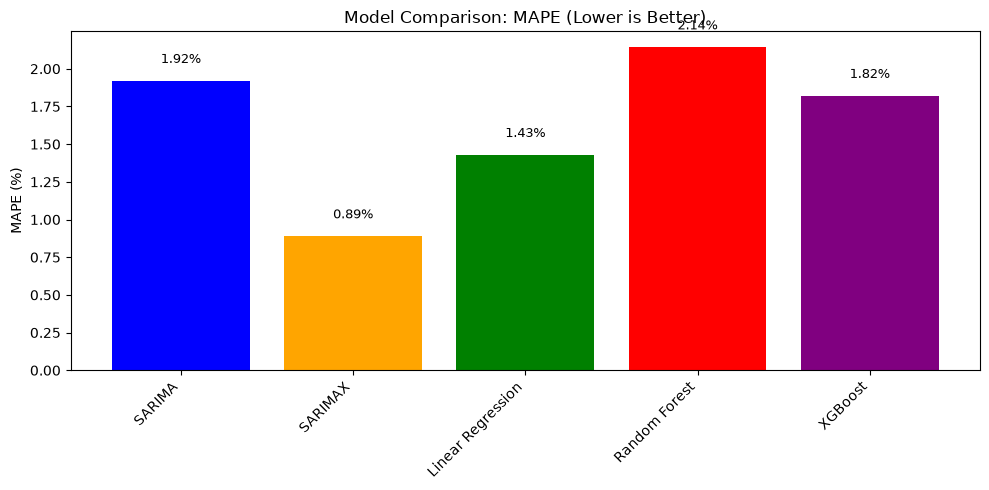


--------------------------------------------------------------------------------
BEST MODEL (by MAPE): SARIMAX


In [255]:

# Bar chart of MAPE

results_df = pd.DataFrame(results)


plt.figure(figsize=(10, 5))
colors = ['b', 'orange', 'green', 'r', 'purple', 'brown', 'pink']

bars = plt.bar(results_df['Model'], results_df['MAPE'], color=colors)
plt.ylabel('MAPE (%)')
plt.title('Model Comparison: MAPE (Lower is Better)')
plt.xticks(rotation=45, ha='right')
for bar, val in zip(bars, results_df['MAPE']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
             f'{val:.2f}%', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

print("\n" + "-"*80)
print("BEST MODEL (by MAPE):", results_df.loc[results_df['MAPE'].idxmin(), 'Model'])
